# Libraries

In [23]:
import pandas as pd
pd.set_option('display.max_columns', None)
import re
import unicodedata
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from pysr import PySRRegressor
import matplotlib.pyplot as plt
import joblib
import json
import itertools

# Read dataset

In [17]:
df_x1 = pd.read_excel('data_models_rv2.xlsx', sheet_name='Dataset_1')
df_x2 = pd.read_excel('data_models_rv2.xlsx', sheet_name='Modelos normativos')
df_y = pd.read_excel('data_models_rv2.xlsx', sheet_name='Modelos')
def clean_column_name(name):
    name = unicodedata.normalize('NFKD', str(name)).encode('ASCII', 'ignore').decode('ASCII')
    name = name.lower()
    name = name.replace(' ', '_')
    name = re.sub(r'[^\w_]', '', name)
    name = re.sub(r'__+', '_', name)
    name = name.strip('_')
    return name
df_x1.columns = [clean_column_name(col) for col in df_x1.columns]
df_x2.columns = [clean_column_name(col) for col in df_x2.columns]
df_y.columns = [clean_column_name(col) for col in df_y.columns]

### Clean first dataset

In [18]:
df_x1.drop(['autor'], inplace=True, axis=1)
print(len(df_x1))
df_x1.head()

341


,diametro_da_armadura_mm,resistencia_do_aco_fy_mpa,numero_de_barras_em_uma_camada,espacamento_entre_as_barras_mm,resistencia_a_tracao_do_concreto_mpa,cobrimento_mm,distancia_ao_centro_de_gravidade_da_armadura_mm,largura_da_viga_b_mm,altura_da_viga_h_mm,area_de_aco_tracionada_as_mm2,taxa_de_armadura_conforme_mc2020,momento_fletor_ms_knm
0,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.0213,20.8
1,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.0213,27.3
2,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.0213,28.2
3,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.0213,32.6
4,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.0213,41.2


### x variables

In [20]:
df_x2.columns

Index(['autor', 'diametro_da_armadura_f_mm', 'numero_de_barras_em_uma_camada',
       'espacamento_entre_as_barras_mm',
       'resistencia_a_tracao_do_concreto_fctm_mpa', 'cobrimento_c_mm',
       'distancia_ao_centro_de_gravidade_da_armadura_d_mm',
       'linha_neutra_no_estadio_ii_xii_mm', 'altura_da_viga_h_mm',
       'altura_efetiva_d_mm', 'linha_neutra_no_estadio_i_xg_mm',
       'altura_efetiva_da_fib_2020_hcef_mm', 'wexp_mm',
       'fib_model_code_2010_wmax', 'tensao_na_armadura_ss_mpa',
       'tensao_na_armadura_no_instante_da_fissuracao_do_concreto_ssr_mpa',
       'taxa_de_armadura', 'wkwexp', 'fib_model_code_2020_wmax',
       'tensao_na_armadura_ss_mpa1',
       'tensao_na_armadura_no_instante_da_fissuracao_do_concreto_ssr_mpa1',
       'taxa_de_armadura1', 'k1r', 'kfl', 'wkwexp1', 'eurocode_2_wmax',
       'tensao_na_armadura_mpa',
       'tensao_na_armadura_no_instante_da_fissuracao_do_concreto_sigmasr_mpa',
       'taxa_de_armadura2', 'wkwexp2', 'nbr_6118_wk1_fissura

In [15]:
df_x2 = df_x2[['fib_model_code_2010_wmax', 'eurocode_2_wmax', 'nbr_6118_wk1_fissuracao_estabilizada', 'nbr_6118_wk2_fissuracao_nao_estabilizada']]
df_x2.head()

,autor,diametro_da_armadura_f_mm,numero_de_barras_em_uma_camada,espacamento_entre_as_barras_mm,resistencia_a_tracao_do_concreto_fctm_mpa,cobrimento_c_mm,distancia_ao_centro_de_gravidade_da_armadura_d_mm,linha_neutra_no_estadio_ii_xii_mm,altura_da_viga_h_mm,altura_efetiva_d_mm,linha_neutra_no_estadio_i_xg_mm,altura_efetiva_da_fib_2020_hcef_mm,wexp_mm,fib_model_code_2010_wmax,tensao_na_armadura_ss_mpa,tensao_na_armadura_no_instante_da_fissuracao_do_concreto_ssr_mpa,taxa_de_armadura,wkwexp,fib_model_code_2020_wmax,tensao_na_armadura_ss_mpa1,tensao_na_armadura_no_instante_da_fissuracao_do_concreto_ssr_mpa1,taxa_de_armadura1,k1r,kfl,wkwexp1,eurocode_2_wmax,tensao_na_armadura_mpa,tensao_na_armadura_no_instante_da_fissuracao_do_concreto_sigmasr_mpa,taxa_de_armadura2,wkwexp2,nbr_6118_wk1_fissuracao_estabilizada,nbr_6118_wk2_fissuracao_nao_estabilizada,tensao_na_armadura_mpa1,taxa_de_armadura3,wkwexp3
0,Viga S200-1.76-20 - Sokolov et al (2021),20.0,2,126.0,4.120341,25.0,39.0,57.361777,201.0,162.0,104,136.5,0.16,0.125734,231.811005,90.135975,0.060724,0.785838,0.086159,231.811005,216,0.0213,1.372713,0.296392,0.538496,0.125292,231.811005,90.135975,0.060724,0.783073,0.262468,0.157380,246.562213,0.0157,0.983623
1,NaN,20.0,2,126.0,4.120341,25.0,39.0,57.361777,201.0,162.0,104,136.5,0.23,0.176982,304.251944,90.135975,0.060724,0.769488,0.147127,304.251944,216,0.0213,1.372713,0.296392,0.639681,0.176359,304.251944,90.135975,0.060724,0.766780,0.344489,0.271111,323.612905,0.0157,1.178744
2,NaN,20.0,2,126.0,4.120341,25.0,39.0,57.361777,201.0,162.0,104,136.5,0.24,0.184078,314.282228,90.135975,0.060724,0.766992,0.155568,314.282228,216,0.0213,1.372713,0.296392,0.648201,0.183430,314.282228,90.135975,0.060724,0.764293,0.355846,0.289281,334.281462,0.0157,1.205338
3,NaN,20.0,2,126.0,4.120341,25.0,39.0,57.361777,201.0,162.0,104,136.5,0.27,0.218769,363.319171,90.135975,0.060724,0.810256,0.196838,363.319171,216,0.0213,1.372713,0.296392,0.729030,0.217999,363.319171,90.135975,0.060724,0.807405,0.411368,0.386596,386.438853,0.0157,1.431836
4,NaN,20.0,2,126.0,4.120341,25.0,39.0,57.361777,201.0,162.0,104,136.5,0.35,0.286574,459.164106,90.135975,0.060724,0.818784,0.277502,459.164106,216,0.0213,1.372713,0.296392,0.792864,0.285566,459.164106,90.135975,0.060724,0.815903,0.519888,0.617471,488.382845,0.0157,1.485395


In [4]:
x = pd.concat([df_x1, df_models], axis=1)
len(x)

342

### y variables

In [ ]:
df_y.head(10)

341

In [63]:
y = df_y['wfib1']
y.head()

0    0.073841
1    0.082873
2    0.084432
3    0.073162
4    0.072498
Name: wfib1, dtype: float64

# Symbolic Regression

### Train and test sets and run

In [ ]:
n_folds = 10
size_test = 0.2
parsimony_levels = [0.001, 0.01]
max_size_levels = [20, 30]
pop_size_levels = [100, 500]
ncycles_per_iteration_levels = [1000]
niterations_levels = [500]
weight_optimize_levels = [0.001]
combs_ = list(itertools.product(parsimony_levels, max_size_levels, pop_size_levels, ncycles_per_iteration_levels, niterations_levels, weight_optimize_levels))
da = pd.DataFrame(combs_, columns=['parsimony', 'max_size', 'pop_size', 'ncycles_per_iteration', 'niterations', 'weight_optimize'])
da

,parsimony,max_size,pop_size,ncycles_per_iteration,niterations,weight_optimize
0,0.001,20,100,1000,300,0.001
1,0.001,20,500,1000,300,0.001
2,0.001,30,100,1000,300,0.001
3,0.001,30,500,1000,300,0.001
4,0.010,20,100,1000,300,0.001
5,0.010,20,500,1000,300,0.001
6,0.010,30,100,1000,300,0.001
7,0.010,30,500,1000,300,0.001


In [ ]:
for j in range(n_folds):
   # Split the data in training and testing sets
   x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=size_test)
   for i, row in da.iterrows():
      # Standardize the features using StandardScaler z-score normalization
      scaler = StandardScaler()
      scaler.fit(x_train)
      dict_res = {}
      for i, col_name in enumerate(x_train.columns):
         dict_res[col_name] = {
            "avg": scaler.mean_[i],
            "std_dev": scaler.scale_[i]
         }
      x_train_scaled = scaler.transform(x_train)
      x_test_scaled = scaler.transform(x_test)

      # Train the PySR model
      model = PySRRegressor(
                              parsimony=row['parsimony'],           
                              maxsize=row['max_size'],
                              maxdepth=None, 
                              population_size=row['pop_size'],
                              ncycles_per_iteration=row['ncycles_per_iteration'],
                              niterations=row['niterations'], 
                              adaptive_parsimony_scaling=50,
                              deterministic=False, 
                              should_optimize_constants=True,
                              optimizer_algorithm="BFGS",
                              optimizer_nrestarts=3,
                              binary_operators=["+", "-", "*", "/"],
                              unary_operators=["sin", "cos", "exp", "sqrt", "log", "abs", "square", "cube"],
                              weight_optimize=row['weight_optimize'],
                              verbosity=0,
                              progress=False,
                              parallelism='multithreading',
                              early_stop_condition=1e-8,
                           )
      model.fit(x_train_scaled, y_train)

      # Statistics and results
      y_pred_train = model.predict(x_train_scaled)
      y_pred_test = model.predict(x_test_scaled)
      rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
      rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
      r2_train = r2_score(y_train, y_pred_train)
      r2_test = r2_score(y_test, y_pred_test)
      print(f"Train RMSE: {rmse_train}")
      print(f"Test RMSE: {rmse_test}")
      print(f"Train R2: {r2_train}")
      print(f"Test R2: {r2_test}")
      best_eq = model.get_best()
      best_equation = best_eq['equation']
      print(f"Best Equation: {best_equation}")
      print("\n\n")
      dict_res['model'] = {
         "train_rmse": rmse_train,
         "test_rmse": rmse_test,
         "train_r2": r2_train,
         "test_r2": r2_test,
         "best_equation": best_equation
      }

      # Save the model and scaler
      with open(f'best_model_fold_{j}_grid_{i}.json', 'w') as f:
         json.dump(dict_res, f, indent=4)

{'diametro_da_armadura_mm': {'media_mu': 17.695, 'desvio_padrao_sigma': 6.317447245991244}, 'resistencia_do_aco_fy_mpa': {'media_mu': 469.5147058823529, 'desvio_padrao_sigma': 102.36863786839767}, 'numero_de_barras_em_uma_camada': {'media_mu': 2.5404411764705883, 'desvio_padrao_sigma': 1.4394074902578422}, 'espacamento_entre_as_barras_mm': {'media_mu': 62.91422794117648, 'desvio_padrao_sigma': 44.217475439104916}, 'resistencia_a_tracao_do_concreto_mpa': {'media_mu': 3.104578260033219, 'desvio_padrao_sigma': 0.5248711858987017}, 'cobrimento_mm': {'media_mu': 32.84518382352941, 'desvio_padrao_sigma': 10.562924024000038}, 'distancia_ao_centro_de_gravidade_da_armadura_mm': {'media_mu': 43.78970588235294, 'desvio_padrao_sigma': 11.815840435940748}, 'largura_da_viga_b_mm': {'media_mu': 203.77573529411765, 'desvio_padrao_sigma': 107.97489052901818}, 'altura_da_viga_h_mm': {'media_mu': 340.4970588235294, 'desvio_padrao_sigma': 114.30750061667797}, 'area_de_aco_tracionada_as_mm2': {'media_mu': 

KeyboardInterrupt: 

### Metrics

In [ ]:
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
print(f"Train RMSE: {rmse_train}")
print(f"Test RMSE: {rmse_test}")
print(f"Train R2: {r2_train}")
print(f"Test R2: {r2_test}")
best_eq = model.get_best()
best_equation = best_eq['equation']
print(f"Best Equation: {best_equation}")

Train RMSE: 0.071151742862969
Test RMSE: 0.08442896683422638
Train R2: 0.31608236272323287
Test R2: 0.17616531635134713
Best Equation: (slip_de_biscaia_e_soares_2020 ^ 10.432643) ^ eurocode_2


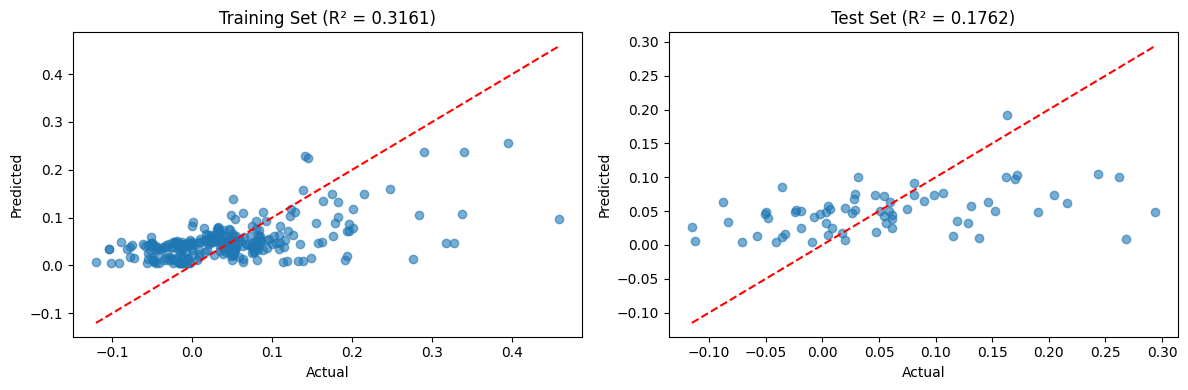

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(y_train, y_pred_train, alpha=0.6)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
ax1.set_xlabel('Actual')
ax1.set_ylabel('Predicted')
ax1.set_title(f'Training Set (R² = {r2_train:.4f})')

ax2.scatter(y_test, y_pred_test, alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title(f'Test Set (R² = {r2_test:.4f})')

plt.tight_layout()
plt.show()

In [ ]:
best_eq = model.get_best()
print(f"Best equation: {best_eq['equation']}")
print(f"Complexity: {best_eq['complexity']} nodes")

Best equation: (slip_de_biscaia_e_soares_2020 ^ 10.432643) ^ eurocode_2
Complexity: 5 nodes


In [ ]:
import sympy as sp
from IPython.display import display, Latex

equation_sympy = model.sympy()
equation_latex = sp.latex(equation_sympy)

table_latex = f"""
\\begin{{array}}{{|l|c|}}
\\hline
\\textbf{{Metric}} & \\textbf{{Value}} \\\\
\\hline
\\text{{Equation}} & {equation_latex} \\\\
\\hline
R^2 \\text{{ (Train)}} & {r2_train:.4f} \\\\
\\hline
R^2 \\text{{ (Test)}} & {r2_test:.4f} \\\\
\\hline
\\text{{RMSE (Train)}} & {rmse_train:.4f} \\\\
\\hline
\\text{{RMSE (Test)}} & {rmse_test:.4f} \\\\
\\hline
\\end{{array}}
"""

display(Latex(table_latex))

<IPython.core.display.Latex object>

In [ ]:
models_pred_df = pd.read_excel("banco de dados daniel.xlsx", "Modelos normativos e empíricos")
y_pred_total = model.predict(X)

models_pred_df["Symbolic Regression"] = None  
for i in range(len(y_pred_total)): 
    models_pred_df.at[i, "Symbolic Regression"] = y_pred_total[i]

models_pred_df["Symbolic Regression"] = pd.to_numeric(
    models_pred_df["Symbolic Regression"], errors="coerce"
)

wexp_col = "wexp (mm)"
for col in models_pred_df.select_dtypes(include="number").columns:
    if col == wexp_col:
        continue
    models_pred_df[f"{col} / wexp"] = models_pred_df[col] / models_pred_df[wexp_col]

models_pred_df.drop(columns=['wexp (mm)', 'fib Model Code 2010', 'fib Model Code 2020', 'Eurocode 2',
       'NBR 6118 - wk1 - fissuração estabilizada',
       'NBR 6118 - wk2 - fissuração não estabilizada', 'Clark (1956)',
       'Leonhardt (1977)', 'Desayi e Ganesan (1985)', 'Oh e Kang (1987)',
       'Caldas (1997)', 'Gergely e Lutz (1968)', ' b  variável e < 0,6',
       'equação (15) do artigo de Belarbi e Hsu (1994)',
       'Beta conforme Fields e Bischoff (2004)', 'slip de Yuan et al. (2025)',
       'slip de Biscaia e Soares (2020)', 'HistGradientBoosting_TS_var',
       'LGBM_TS_var', 'GradientBoosting_TS_var', 'HistGradientBoosting_sem_TS',
       'LGBM_sem_TS', 'GradientBoosting_sem_TS', 'Symbolic Regression'], inplace=True)

numeric_df = models_pred_df.select_dtypes(include="number")
desc = numeric_df.describe().T
desc["skewness"] = numeric_df.skew()
desc["kurtosis"] = numeric_df.kurtosis()
desc_rounded = desc.round(2).drop(columns=["count"])
desc_rounded

FileNotFoundError: [Errno 2] No such file or directory: 'banco de dados daniel.xlsx'